# Variables and Data types
___

## Understanding Variables

In statistical studies, variables denote characteristics of the subjects under analysis. Selecting appropriate variables is pivotal in designing successful experiments, as they help anticipate outcomes.

For instance, when predicting house prices, variables like the number of bedrooms, location, age, amenities nearby, and presence of a garage or pool are considered. These factors, aiding in price prediction, are termed variables.

## Independent and Dependent Variables

**Independent Variable**: Also known as explanatory or predictor variables, these are factors manipulated in an experiment to observe their impact on outcomes. They represent causes and are not influenced by other study variables.

**Dependent Variable**: Referred to as response or outcome variables, these are observed results of an experiment. They represent effects and their values depend on changes made to the independent variable.

## Types of Data

Data, crucial for understanding relationships between variables, making predictions, and supporting decision-making, comes in various types. To accurately analyze and interpret data, it's essential to comprehend these types:

**Quantitative Data**: Deals with quantities and measurements and can be either continuous or discrete. Continuous data refers to uninterrupted values along a scale, like distance and time. Discrete data, however, refers to specific values, like the number of students in a class or the outcome of rolling a die.

**Categorical Data**: Represents groupings and is further categorized into nominal, ordinal, and binary types. Nominal data assigns values to categories without any inherent order, such as people's names and colors. Ordinal data, in contrast, assigns values with an order, like rating levels and grades. Binary data, the simplest form, has only two possible values, such as heads or tails in a coin flip, or yes or no.


## Measurement Scales

Measurement scales, also referred to as levels of measurement, elucidate how precisely variables are recorded in scientific research. Here, a variable denotes any attribute capable of assuming different values in a dataset (e.g., height, test scores).

There exist four measurement scales:

- **Nominal**: Data can only be categorized.
- **Ordinal**: Data can be categorized and ordered.
- **Interval**: Data can be categorized, ordered, and equally spaced.
- **Ratio**: Data can be categorized, ordered, equally spaced, and possess a true zero point.

The level of measurement for a variable profoundly influences the types of analyses feasible on it. Ranging from nominal (low) to ratio (high), measurement scales vary in complexity and precision.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(seed=42)
n = 200

df = pd.DataFrame({
    'neighborhood'    : rng.choice(['A','B','C','D'], size=n),          # Nominal
    'satisfaction'    : rng.choice(['Poor','Fair','Good','Excellent'], size=n),  # Ordinal
    'num_bedrooms'    : rng.integers(1, 6, size=n),                     # Discrete
    'house_price_usd' : rng.normal(350_000, 80_000, size=n).clip(100_000),  # Continuous
})
df['neighborhood'] = pd.Categorical(df['neighborhood'])
df['satisfaction'] = pd.Categorical(
    df['satisfaction'],
    categories=['Poor','Fair','Good','Excellent'], ordered=True
)

print('Variable types:')
print(df.dtypes.to_string())
print()
df.head()


Variable types:
neighborhood       category
satisfaction       category
num_bedrooms          int64
house_price_usd     float64



,neighborhood,satisfaction,num_bedrooms,house_price_usd
0,A,Fair,5,326626.305136
1,D,Excellent,4,341720.938555
2,C,Fair,2,329841.809743
3,B,Good,5,362205.000968
4,B,Fair,3,467719.357839


### Summary Statistics by Variable Type

- **Nominal / Ordinal** → frequency counts and mode  
- **Discrete / Continuous** → mean, median, standard deviation

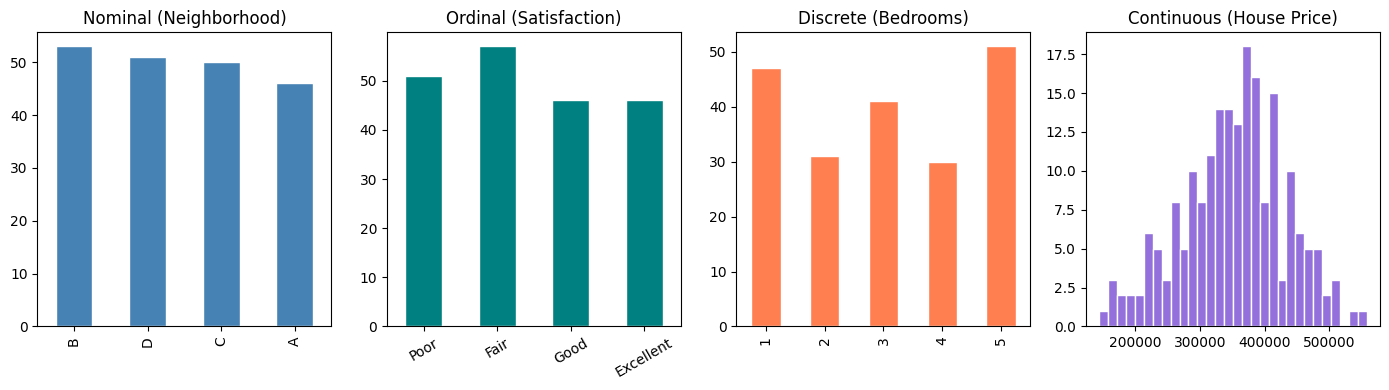

Nominal  - mode: B
Ordinal  - mode: Fair
Discrete - mean bedrooms: 3.04
Continuous - mean price: $352,479, median: $357,346


In [2]:
fig, axes = plt.subplots(1, 4, figsize=(14, 4))

df['neighborhood'].value_counts().plot.bar(
    ax=axes[0], color='steelblue', edgecolor='white', title='Nominal (Neighborhood)')

df['satisfaction'].value_counts().sort_index().plot.bar(
    ax=axes[1], color='teal', edgecolor='white', title='Ordinal (Satisfaction)')
axes[1].tick_params(axis='x', rotation=30)

df['num_bedrooms'].value_counts().sort_index().plot.bar(
    ax=axes[2], color='coral', edgecolor='white', title='Discrete (Bedrooms)')

axes[3].hist(df['house_price_usd'], bins=30, color='mediumpurple', edgecolor='white')
axes[3].set_title('Continuous (House Price)')
axes[3].set_xlabel('USD')

for ax in axes:
    ax.set_xlabel('')

plt.tight_layout()
plt.show()

print('Nominal  - mode:', df['neighborhood'].mode()[0])
print('Ordinal  - mode:', df['satisfaction'].mode()[0])
print(f'Discrete - mean bedrooms: {df["num_bedrooms"].mean():.2f}')
print(f'Continuous - mean price: ${df["house_price_usd"].mean():,.0f}, median: ${df["house_price_usd"].median():,.0f}')


---
## ML/AI Connection

- **Feature engineering** critically depends on variable type: one-hot encoding for nominal, ordinal encoding for ordinal, normalisation for continuous, count features for discrete.
- **Loss function choice** depends on the output variable type: cross-entropy for nominal targets, MSE for continuous, ordinal regression for ordered categories.
- **pandas dtypes** matter for ML pipelines — `Categorical` dtype enables efficient encoding; numeric dtypes feed directly into sklearn transformers.
